In [ ]:
from google.colab import files
uploaded = files.upload()

Saving german_credit_data.csv to german_credit_data.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

uci = pd.read_csv("UCI_Credit_Card.csv")
german = pd.read_csv("german_credit_data.csv")

Saving UCI_Credit_Card.csv to UCI_Credit_Card (1).csv


In [ ]:
print(german.columns)

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')


In [ ]:
from google.colab import files
uploaded = files.upload()

uci = pd.read_csv("UCI_Credit_Card.csv")
german = pd.read_csv("german_credit_data.csv")

Saving german_credit_data.csv to german_credit_data (1).csv


In [ ]:
uci.rename(columns={
    'default.payment.next.month': 'default'
}, inplace=True)

Saving german_credit_data.csv.zip to german_credit_data.csv (2).zip
Saving UCI_Credit_Card.csv.zip to UCI_Credit_Card.csv (2).zip
Datasets Uploaded ✅
UCI DataFrame columns: Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target'],
      dtype='object')
Target column created for German Dataset ✅

========== UCI Credit Card Dataset ==========

Random Forest
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      4673
           1       0.52      0.49      0.50      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.68      0.68      6000
weighted avg       0.78      0.79      0.78      6000

ROC-AUC: 0.7471072335730392


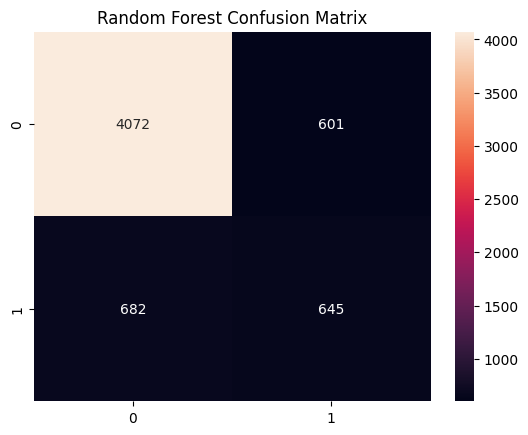


XGBoost
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      4673
           1       0.48      0.47      0.48      1327

    accuracy                           0.77      6000
   macro avg       0.67      0.66      0.66      6000
weighted avg       0.77      0.77      0.77      6000

ROC-AUC: 0.7317008626413083


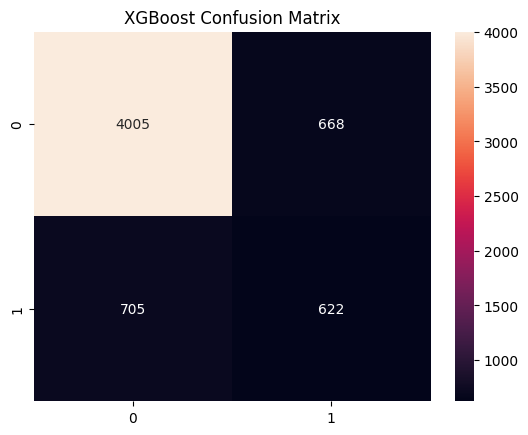


Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.72      0.78      4673
           1       0.37      0.58      0.45      1327

    accuracy                           0.69      6000
   macro avg       0.61      0.65      0.62      6000
weighted avg       0.75      0.69      0.71      6000

ROC-AUC: 0.6914229816107573


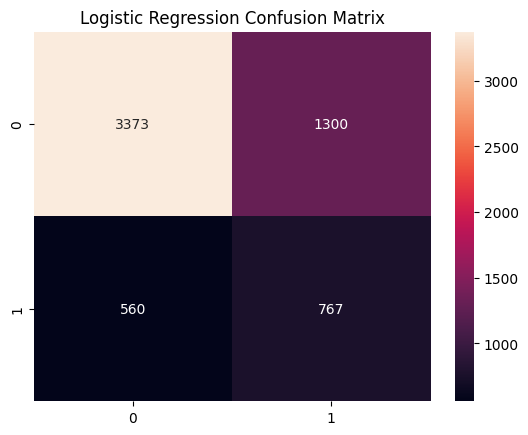


🏆 BEST MODEL: Random Forest

========== German Credit Dataset ==========

Random Forest
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       130
           1       1.00      0.99      0.99        70

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

ROC-AUC: 0.99989010989011


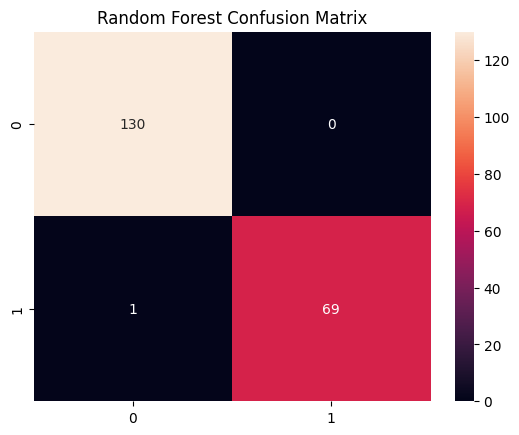


XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       130
           1       1.00      1.00      1.00        70

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

ROC-AUC: 1.0


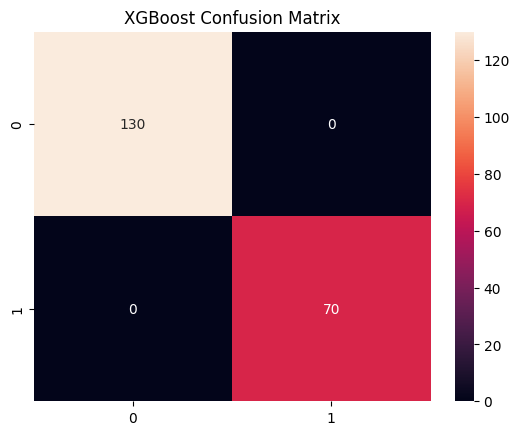


Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       130
           1       0.89      0.96      0.92        70

    accuracy                           0.94       200
   macro avg       0.93      0.95      0.94       200
weighted avg       0.95      0.94      0.95       200

ROC-AUC: 0.977032967032967


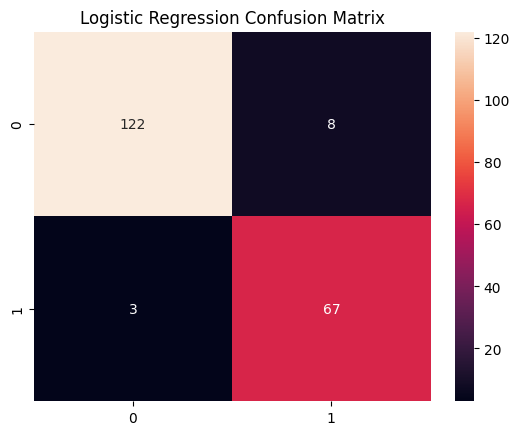


🏆 BEST MODEL: XGBoost


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

uploaded = files.upload()

uci = pd.read_csv("UCI_Credit_Card.csv")
german = pd.read_csv("german_credit_data.csv")

print("Datasets Uploaded ✅")

print("UCI DataFrame columns:", uci.columns)

uci.rename(columns={
    'target': 'default'
}, inplace=True)


german.drop(columns=['Unnamed: 0'], inplace=True)

german.fillna("Unknown", inplace=True)

german['default'] = np.where(
    (german['Credit amount'] > german['Credit amount'].median()) &
    (german['Duration'] > german['Duration'].median()),
    1, 0
)

print("Target column created for German Dataset ✅")


def train_models(data, name):

    print(f"\n========== {name} ==========")

    X = data.drop('default', axis=1)
    y = data['default']

    X = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    rf = RandomForestClassifier(n_estimators=200, random_state=42)

    xgb = XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )

    lr = LogisticRegression(max_iter=1000)

    models = {
        "Random Forest": rf,
        "XGBoost": xgb,
        "Logistic Regression": lr
    }

    results = {}

    for name_model, model in models.items():

        model.fit(X_train, y_train)

        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:,1]

        auc = roc_auc_score(y_test, prob)
        results[name_model] = auc

        print(f"\n{name_model}")
        print(classification_report(y_test, pred))
        print("ROC-AUC:", auc)

        plt.figure()
        sns.heatmap(confusion_matrix(y_test, pred),
                    annot=True, fmt="d")
        plt.title(f"{name_model} Confusion Matrix")
        plt.show()

    print("\n🏆 BEST MODEL:",
          max(results, key=results.get))

train_models(uci, "UCI Credit Card Dataset")

train_models(german, "German Credit Dataset")

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = uci.drop("default", axis=1)
y = uci["default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7592 - loss: 0.5256
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8175 - loss: 0.4404
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8178 - loss: 0.4380
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8233 - loss: 0.4271
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8219 - loss: 0.4264
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8222 - loss: 0.4294
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8241 - loss: 0.4228
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8258 - loss: 0.4171
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8279 - loss: 0.4224
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8257 - loss: 0.4214
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8256 - loss: 0.4212
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy

In [ ]:
from tensorflow.keras.layers import Conv1D, Flatten, MaxPooling1D
from tensorflow.keras.models import Sequential

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn_model = Sequential()

cnn_model.add(Conv1D(32, 2, activation='relu', input_shape=(X_train_cnn.shape[1],1)))
cnn_model.add(MaxPooling1D(2))
cnn_model.add(Flatten())

cnn_model.add(Dense(16, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

cnn_model.fit(X_train_cnn, y_train, epochs=20, batch_size=32)

y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)

print("CNN Accuracy:", accuracy_score(y_test, y_pred_cnn))
print(confusion_matrix(y_test, y_pred_cnn))
print(classification_report(y_test, y_pred_cnn))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7962 - loss: 0.4812
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8149 - loss: 0.4404
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8186 - loss: 0.4356
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8191 - loss: 0.4308
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8251 - loss: 0.4246
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8222 - loss: 0.4244
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8192 - loss: 0.4306
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8216 - loss: 0.4299
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8245 - loss: 0.4276
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8212 - loss: 0.4264
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8146 - loss: 0.4389
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

In [4]:
import pandas as pd
import zipfile
from google.colab import files

uploaded = files.upload()

# -------- UCI ZIP --------
with zipfile.ZipFile("UCI_Credit_Card.csv.zip", 'r') as zip_ref:
    zip_ref.extract("UCI_Credit_Card.csv")

uci = pd.read_csv("UCI_Credit_Card.csv")

# -------- German ZIP --------
with zipfile.ZipFile("german_credit_data.csv.zip", 'r') as zip_ref:
    zip_ref.extract("german_credit_data.csv")

german = pd.read_csv("german_credit_data.csv")

print("Both datasets loaded successfully ✅")

Saving german_credit_data.csv.zip to german_credit_data.csv (2).zip
Saving UCI_Credit_Card.csv.zip to UCI_Credit_Card.csv (2).zip
Both datasets loaded successfully ✅


In [5]:

# RNN + LSTM FOR BOTH DATASETS

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Input

# DATA PREPARATION FUNCTION

def prepare_data_for_dl(data, dataset_name):
    print(f"\n===== Preparing {dataset_name} Dataset =====")

    data = data.copy()

    # UCI dataset target fix
    if dataset_name == "UCI Credit Card Dataset":
        if "default" not in data.columns:
            data.rename(columns={"default.payment.next.month": "default"}, inplace=True)

    # German dataset preprocessing
    if dataset_name == "German Credit Dataset":
        if "Unnamed: 0" in data.columns:
            data.drop(columns=["Unnamed: 0"], inplace=True)

        data.fillna("Unknown", inplace=True)

        if "default" not in data.columns:
            data["default"] = np.where(
                (data["Credit amount"] > data["Credit amount"].median()) &
                (data["Duration"] > data["Duration"].median()),
                1, 0
            )

    # Features and target
    X = data.drop("default", axis=1)
    y = data["default"]

    # Convert categorical to numeric
    X = pd.get_dummies(X, drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Reshape for RNN/LSTM
    X_train_seq = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_seq = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    return X_train_seq, X_test_seq, y_train, y_test


# RNN FUNCTION

def run_rnn(data, dataset_name):
    X_train_seq, X_test_seq, y_train, y_test = prepare_data_for_dl(data, dataset_name)

    print(f"\n===== RNN on {dataset_name} =====")

    rnn_model = Sequential()
    rnn_model.add(Input(shape=(X_train_seq.shape[1], 1)))
    rnn_model.add(SimpleRNN(32, activation='tanh'))
    rnn_model.add(Dense(16, activation='relu'))
    rnn_model.add(Dense(1, activation='sigmoid'))

    rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    rnn_model.fit(
        X_train_seq, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    y_pred_rnn = (rnn_model.predict(X_test_seq) > 0.5).astype(int)

    print("\nRNN Accuracy:", accuracy_score(y_test, y_pred_rnn))
    print(confusion_matrix(y_test, y_pred_rnn))
    print(classification_report(y_test, y_pred_rnn))


# LSTM FUNCTION

def run_lstm(data, dataset_name):
    X_train_seq, X_test_seq, y_train, y_test = prepare_data_for_dl(data, dataset_name)

    print(f"\n===== LSTM on {dataset_name} =====")

    lstm_model = Sequential()
    lstm_model.add(Input(shape=(X_train_seq.shape[1], 1)))
    lstm_model.add(LSTM(32, activation='tanh'))
    lstm_model.add(Dense(16, activation='relu'))
    lstm_model.add(Dense(1, activation='sigmoid'))

    lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    lstm_model.fit(
        X_train_seq, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    y_pred_lstm = (lstm_model.predict(X_test_seq) > 0.5).astype(int)

    print("\nLSTM Accuracy:", accuracy_score(y_test, y_pred_lstm))
    print(confusion_matrix(y_test, y_pred_lstm))
    print(classification_report(y_test, y_pred_lstm))

# RUN ON BOTH DATASETS

run_rnn(uci, "UCI Credit Card Dataset")
run_lstm(uci, "UCI Credit Card Dataset")

run_rnn(german, "German Credit Dataset")
run_lstm(german, "German Credit Dataset")


===== Preparing UCI Credit Card Dataset Dataset =====

===== RNN on UCI Credit Card Dataset =====
Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7990 - loss: 0.4764 - val_accuracy: 0.8010 - val_loss: 0.4622
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8094 - loss: 0.4490 - val_accuracy: 0.8035 - val_loss: 0.4546
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8127 - loss: 0.4425 - val_accuracy: 0.8094 - val_loss: 0.4597
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8141 - loss: 0.4394 - val_accuracy: 0.8004 - val_loss: 0.4588
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8151 - loss: 0.4385 - val_accuracy: 0.8050 - val_loss: 0.4552
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8192 - loss: 0.4342 - val_accuracy: 0.8077 - val_loss: 0.4529
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8189 - loss: 0.4333 - val_accuracy: 0.8094 - val_loss: 0.4517
Epoch

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

LSTM Accuracy: 0.85
[[120  10]
 [ 20  50]]
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       130
           1       0.83      0.71      0.77        70

    accuracy                           0.85       200
   macro avg       0.85      0.82      0.83       200
weighted avg       0.85      0.85      0.85       200

